In [1]:
import pandas as pd
import sys
sys.path.append("..")

from features import extract_features, FEATURE_COLUMNS

df = pd.read_csv("../data/cleaned_malicious_phish.csv")   

df_features = extract_features(df)
df_features[FEATURE_COLUMNS]

label_map = {"benign": 0, "phishing": 1, "malware": 1, "defacement": 1}
df["label"] = df["type"].map(label_map)

In [2]:
import tldextract
from sklearn.model_selection import GroupShuffleSplit
def get_domain(url):
    ext = tldextract.extract(url)
    return f"{ext.domain}.{ext.suffix}"

df["domain"] = df["url"].apply(get_domain)

X = df_features[FEATURE_COLUMNS]
y = df["label"]
groups = df["domain"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in gss.split(X,y,groups):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]
    
print(X_train.shape, X_test.shape)


(519881, 4) (121244, 4)


In [3]:
from sklearn.linear_model import LogisticRegression
final_model = LogisticRegression(random_state=42, class_weight="balanced", C=0.01)
final_model.fit(X_train, y_train)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.01
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good defaul

In [4]:
from sklearn.metrics import classification_report
y_pred = final_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.71      0.76     80073
           1       0.54      0.68      0.60     41171

    accuracy                           0.70    121244
   macro avg       0.68      0.69      0.68    121244
weighted avg       0.72      0.70      0.70    121244



## Finding

Honest test f1 ≈ 0.60, matching CV, with recall prioritized over precision — appropriate for threat detection.

In [5]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[56700, 23373],
       [13286, 27885]])

In [8]:
missed_mask = (y_test.values == 1) & (y_pred == 0)
missed_mask.sum()   # should be 13286


np.int64(13286)

In [9]:
test_types = df["type"].iloc[test_idx].values   # types of test rows, as an aligned array
missed_types = test_types[missed_mask]           # types of just the missed threats

In [10]:
import pandas as pd
pd.Series(missed_types).value_counts()

defacement    5997
phishing      5434
malware       1855
Name: count, dtype: int64

## Finding

Missed threats track each attack type's overall prevalence — defacement and phishing dominate the misses simply because they dominate the data. Malware is modestly over-represented among failures (14% of misses vs 11% of malicious URLs), consistent with its being the least-represented class, but the effect is small; the model fails fairly uniformly rather than collapsing on one attack type.

In [11]:
malicious_types = test_types[y_test.values == 1]
total_by_type = pd.Series(malicious_types).value_counts()

missed_by_type = pd.Series(missed_types).value_counts()

miss_rate = missed_by_type / total_by_type
print(miss_rate)

defacement    0.306658
phishing      0.316667
malware       0.416386
Name: count, dtype: float64


## Finding

Per-type recall reveals the model catches defacement (69%) and phishing (68%) comparably, but malware recall falls to 58% — a ~10-point gap. Malware is the least-represented class (~11% of malicious URLs), so the model had the least signal to learn it, and its detection suffers accordingly.

In [12]:
y_scores = final_model.predict_proba(X_test)[:, 1]

In [13]:
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

In [14]:
from sklearn.metrics import average_precision_score
average_precision_score(y_test, y_scores)

0.5445753908980897

In [22]:
ap = average_precision_score(y_test, y_scores)

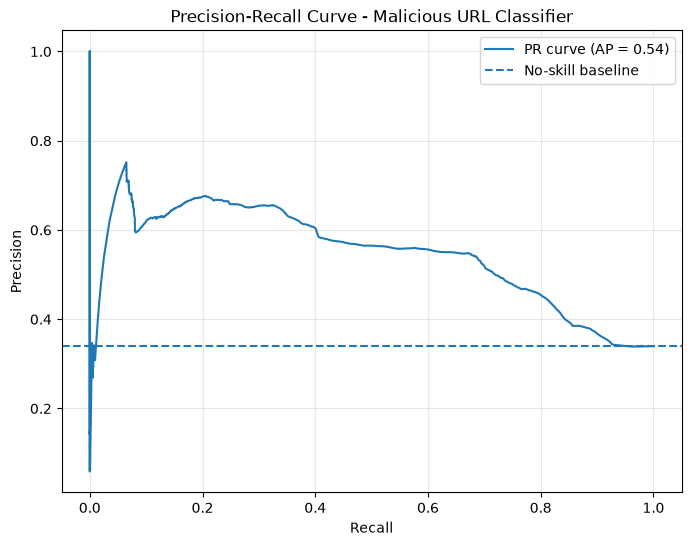

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f"PR curve (AP = {ap:.2f})")
plt.axhline(y=y_test.mean(), linestyle="--", label="No-skill baseline")
plt.title("Precision-Recall Curve - Malicious URL Classifier")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("../images/pr_curve.png", dpi=300, bbox_inches="tight")
plt.show()
